In [1]:
#@title Imports
import torch, torch.nn as nn, torch.nn.functional as F, torchvision
from torch.utils.data import Subset, DataLoader
from torchvision import transforms, datasets, models
import numpy as np, matplotlib.pyplot as plt

In [2]:
#@title Device
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [14]:
#@title Variables
BATCH_SIZE = 12
ATTENTION_HEADS = 4
TRANSFORMER_LAYERS = 4
EMBED_DIM = 16
IMG_SIZE = 28
PATCH_SIZE = 7
CLASSES = 10
EPOCHS_STUDENT = 100
LR_STUDENT = 1e-4
TEMPERATURE = 4
ALPHA = 0.1
CHANNELS = 3

In [4]:
#@title Data
tfm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda t: t.repeat(3,1,1)),
])
train_full = datasets.MNIST('./data', train=True, download=True, transform=tfm)
test = datasets.MNIST('./data', train=False, download=True, transform=tfm)

n = int(0.1 * len(train_full))
subset_idx = np.random.permutation(len(train_full))[:n]
train = Subset(train_full, subset_idx)

train_dl = DataLoader(train, batch_size=BATCH_SIZE, shuffle=True)
test_dl = DataLoader(test, batch_size=BATCH_SIZE)

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.94MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 130kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.1MB/s]


In [5]:
teacher = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
teacher.fc = nn.Linear(teacher.fc.in_features, CLASSES)
teacher.to(device)

# Freeze all layers except the classification layer
for param in teacher.parameters():
    param.requires_grad = False

# Unfreeze the final classification layer
for param in teacher.fc.parameters():
    param.requires_grad = True

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 186MB/s]


In [6]:
#@title Student ViT
class PatchEmbed(nn.Module):
    def __init__(self, img_size=IMG_SIZE, patch=PATCH_SIZE, dim=EMBED_DIM, channels = CHANNELS):
        super().__init__()
        self.proj=nn.Conv2d(CHANNELS,dim,patch,patch)
        self.n=(img_size//patch)**2
    def forward(self,x):
        x=self.proj(x).flatten(2).transpose(1,2)
        return x

class ViT(nn.Module):
    def __init__(self,num_classes=CLASSES,dim=EMBED_DIM,depth=TRANSFORMER_LAYERS,heads=ATTENTION_HEADS):
        super().__init__()
        self.patch=PatchEmbed()
        n=self.patch.n
        self.cls=nn.Parameter(torch.zeros(1,1,dim))
        self.distill=nn.Parameter(torch.zeros(1,1,dim))
        self.pos=nn.Parameter(torch.zeros(1,n+2,dim))
        self.blocks = nn.Sequential(*[
            nn.TransformerEncoderLayer(dim, heads, dim*4, batch_first=True)
            for _ in range(depth)
        ])
        self.norm=nn.LayerNorm(dim)
        self.head_cls=nn.Linear(dim,num_classes)
        self.head_dist=nn.Linear(dim,num_classes)

    def forward(self,x):
        B=x.size(0)
        x=self.patch(x)
        cls=self.cls.expand(B,-1,-1)
        dist=self.distill.expand(B,-1,-1)
        x=torch.cat([cls,x,dist],1)+self.pos
        x = self.blocks(x)
        x=self.norm(x)
        cls_out=x[:,0]; dist_out=x[:,-1]
        cls_logits=self.head_cls(cls_out)
        dist_logits=self.head_dist(dist_out)
        return cls_logits, dist_logits

student=ViT().to(device)
opt_s=torch.optim.AdamW(student.parameters(),lr=LR_STUDENT)

In [15]:
#@title Train Student with Hard Distillation
def kd_loss(s_logits, t_logits, y, T=TEMPERATURE, alpha = ALPHA):
    kd = F.kl_div(F.softmax(s_logits/T,dim=1),
                  F.softmax(t_logits/T,dim=1),
                  reduction='batchmean') * (T*T)
    ce = F.cross_entropy(s_logits, y)
    return alpha*kd + (1-alpha)*ce

print("Training student...")
for e in range(EPOCHS_STUDENT):
    student.train()
    for x, y in train_dl:
        x, y = x.to(device), y.to(device)
        with torch.no_grad():
            t_logits = teacher(x)                          #A
        cls_logits, dist_logits = student(x)               #B
        loss_cls = F.cross_entropy(cls_logits, y)          #C
        loss_distill = kd_loss(dist_logits, t_logits, y)   #D
        loss = loss_cls + loss_distill                     #E
        opt_s.zero_grad()                                  #F
        loss.backward()
        opt_s.step()
    print(f"Epoch {e+1} done")

Training student...
Epoch 1 done
Epoch 2 done
Epoch 3 done
Epoch 4 done
Epoch 5 done
Epoch 6 done
Epoch 7 done
Epoch 8 done
Epoch 9 done
Epoch 10 done
Epoch 11 done
Epoch 12 done
Epoch 13 done
Epoch 14 done
Epoch 15 done
Epoch 16 done
Epoch 17 done
Epoch 18 done
Epoch 19 done
Epoch 20 done
Epoch 21 done
Epoch 22 done
Epoch 23 done
Epoch 24 done
Epoch 25 done
Epoch 26 done
Epoch 27 done
Epoch 28 done
Epoch 29 done
Epoch 30 done
Epoch 31 done
Epoch 32 done
Epoch 33 done
Epoch 34 done
Epoch 35 done
Epoch 36 done
Epoch 37 done
Epoch 38 done
Epoch 39 done
Epoch 40 done
Epoch 41 done
Epoch 42 done
Epoch 43 done
Epoch 44 done
Epoch 45 done
Epoch 46 done
Epoch 47 done
Epoch 48 done
Epoch 49 done
Epoch 50 done
Epoch 51 done
Epoch 52 done
Epoch 53 done
Epoch 54 done
Epoch 55 done
Epoch 56 done
Epoch 57 done
Epoch 58 done
Epoch 59 done
Epoch 60 done
Epoch 61 done
Epoch 62 done
Epoch 63 done
Epoch 64 done
Epoch 65 done
Epoch 66 done
Epoch 67 done
Epoch 68 done
Epoch 69 done
Epoch 70 done
Epoch 71 

In [16]:
#@title Evaluate & Show Samples
student.eval()
correct=0; total=0
samples=[]
with torch.no_grad():
    for x,y in test_dl:
        x,y=x.to(device),y.to(device)
        cls_logits,dist_logits=student(x)
        cls_dist = (cls_logits+dist_logits)/2
        pred=cls_dist.argmax(1)
        correct+=(pred==y).sum().item(); total+=y.size(0)
        if len(samples)<15:
            samples.append((x.cpu(),pred.cpu(),y.cpu()))
acc=100*correct/total
print(f"Test Accuracy: {acc:.2f}%")

Test Accuracy: 94.44%


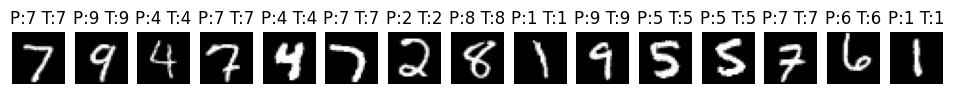

In [17]:
#@title Display predictions
fig,axs=plt.subplots(1,len(samples),figsize=(12,3))
for i,(img,pred,true) in enumerate(samples):
    img=(img[0].permute(1,2,0).numpy())
    axs[i].imshow(img)
    axs[i].set_title(f"P:{pred[0].item()} T:{true[0].item()}")
    axs[i].axis('off')
plt.show()